# Development and Microfinance: Evidence of a Middle-Income Peak in Kiva Lending
ECO225 – Project Two  
Kexing Yan  
Professor Khazra  
Date: 2026-03-06

## Introduction

Microfinance is often described as a tool for expanding credit access where formal banking systems are thin, but the empirical literature does not support a simple view that more poverty automatically implies more successful microfinance. Early survey and review work emphasizes both the promise and the limits of microfinance, especially the tension between outreach to poor borrowers and the operational realities of lending in weak institutional environments (Morduch, 1999). A second strand of work studies microfinance institutions directly and argues that financial sustainability, commercialization, and outreach often move together only imperfectly. Cull, Demirgüç-Kunt, and Morduch (2007, 2009) show that institutions can scale, but doing so may involve trade-offs between profitability and reaching poorer clients. Hermes, Lensink, and Meesters (2011) similarly find that deeper outreach can be associated with lower operating efficiency.

A third strand asks whether microcredit actually improves welfare for poor households. Some influential studies report gains in access to credit and business activity but more limited average effects on broader welfare outcomes. Banerjee, Duflo, Glennerster, and Kinnan (2015), Angelucci, Karlan, and Zinman (2015), Tarozzi, Desai, and Johnson (2015), and Karlan and Zinman (2011) all contribute to a more cautious consensus: microcredit may help some borrowers and relax constraints, but average poverty effects are not universally large or immediate. This more skeptical perspective is reinforced by replication and reanalysis work such as Roodman and Morduch (2014), which highlights how sensitive headline claims can be to identification choices and model specification. At the same time, classic work on financial access and poverty, such as Pitt and Khandker (1998) and Burgess and Pande (2005), keeps attention on the idea that credit access can matter, especially when it expands into underserved places.

These papers are highly relevant, but most focus on either household-level treatment effects or institution-level performance. My project asks a different question at the country-year level: **where is platform-based microfinance most active across countries, and how does that activity vary with economic development and institutional quality?** This is a useful complement to the existing literature because country-level Kiva lending data capture the geographic allocation of microfinance activity rather than only average borrower outcomes or the internal efficiency of a single lender. The broader development environment may matter in two opposing ways. In very poor countries, demand for credit can be high, but weak infrastructure, thin markets, and limited institutional capacity may constrain scale. In rich countries, formal finance may substitute for microfinance. These forces suggest a nonlinear pattern in which microfinance activity peaks not in the poorest countries, but in lower-middle income economies where demand remains strong and delivery conditions are more workable.

The project therefore studies an **X → Y through Z** framework. The outcome **Y** is Kiva lending intensity, measured primarily by total loan volume and loans per capita at the country-year level. The main explanatory variable **X** is economic development, proxied by log GDP per capita. The mechanism **Z** is institutional quality and financial access, which may shape whether development translates into greater or lower microfinance activity. This framing also helps organize the outside data merge: Kiva lending data are combined with World Bank macroeconomic indicators, governance variables, and country-level population measures to build a panel suitable for descriptive analysis, maps, and regression models.

My main message is that microfinance lending activity follows an **inverted U-shaped development pattern**. Lending is not concentrated in the poorest countries, nor does it keep rising with income. Instead, it appears to be strongest in lower-middle income settings and then declines as countries become richer and formal financial systems deepen. Relative to the literature, this project contributes a country-level platform perspective: rather than asking whether one specific microloan increased consumption or whether one institution became more efficient, it asks how the broader development environment is associated with the spatial distribution of microfinance activity across countries.

The rest of the paper proceeds as follows. **Project One** revisits the cleaned country-year dataset, the merge with external datasets, summary statistics, and descriptive figures. **Project Two** then states the main empirical message, uses maps to show cross-country patterns, and estimates a set of linear, interaction, and nonlinear regressions to evaluate whether the development–microfinance relationship is monotonic or instead peaks at intermediate income levels.


# Project One

## 1.1 Introduction

Project One establishes the data structure and descriptive evidence used in the final paper. The central descriptive question is whether Kiva lending is concentrated in the poorest countries, or whether lending activity instead appears strongest in countries that have moved beyond extreme poverty but have not yet developed fully mature financial systems. To answer that question, I construct a country-year panel, define the main X, Y, and Z variables, and compare lending patterns across countries with different levels of development.

## 1.2 Data Cleaning/Loading

The main dataset begins with Kiva loan-level information and aggregates it to the **country-year** level for the period **2013–2017**. I sum loan amounts and loan counts within each country-year and then merge those aggregates with country-level development and institutional variables. Observations with missing values in core regression variables are removed to create the final analysis sample.

The final panel contains country-year observations with the following main variables:

- **Y: Kiva lending activity**, measured by **log_total_loan_amount** and, in descriptive mapping, **loan_per_capita**.
- **X: Economic development**, measured by **log_gdp_pc**.
- **Z: Institutional environment**, measured by **institutional_pca1**, with alternative robustness measures including **institutional_index** and **financial_access_index**.
- **Controls**, especially **log_population**, to account for country size.

This structure allows me to compare microfinance activity across countries while separating differences in economic development, institutional quality, and scale.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

root = Path(".")
reg = pd.read_csv(root / "outputs" / "final_panel_country_year.csv")

# standardize key variables
for col in [
    "log_total_loan_amount",
    "total_loan_amount",
    "log_gdp_pc",
    "institutional_pca1",
    "institutional_index",
    "financial_access_index",
    "population",
    "log_population",
    "poverty_rate",
    "year"
]:
    if col in reg.columns:
        reg[col] = pd.to_numeric(reg[col], errors="coerce")

reg["country_code"] = reg["country_code"].astype(str).str.strip().str.upper()

print("Rows:", len(reg))
print("Columns:", reg.columns.tolist())

reg.head()

Rows: 357
Columns: ['country_code', 'year', 'n_loans', 'total_loan_amount', 'log_total_loan_amount', 'log_gdp_pc', 'population', 'log_population', 'institutional_pca1', 'institutional_index', 'financial_access_index', 'poverty_rate']


,country_code,year,n_loans,total_loan_amount,log_total_loan_amount,log_gdp_pc,population,log_population,institutional_pca1,institutional_index,financial_access_index,poverty_rate
0,AF,2015,1,6000.0,8.699515,6.337834,35530081.0,17.385890,-2.080862,-1.808621,-0.806494,NaN
1,AF,2016,1,8000.0,8.987197,6.334828,35530081.0,17.385890,-2.080862,-1.808621,-0.806494,NaN
2,AL,2013,3,5850.0,8.674197,8.267680,2930187.0,14.890577,0.495336,0.418917,0.331676,NaN
3,AL,2014,603,902550.0,13.712979,8.305266,2930187.0,14.890577,0.495336,0.418917,0.331676,3.7
4,AL,2015,638,844375.0,13.646352,8.342730,2930187.0,14.890577,0.495336,0.418917,0.331676,1.1


### 1.2.1 Merging with External Datasets

To enrich the country-year Kiva panel, I merge in multiple external datasets. These outside datasets are essential because the original Kiva data describe lending activity, but they do not by themselves measure cross-country development, institutional quality, or population size.

**First, I merge a World Bank GDP dataset** containing annual GDP per capita in constant 2015 USD. This dataset is used to construct **gdp_pc_const2015** and **log_gdp_pc**, which serve as the main explanatory variables for economic development.

**Second, I merge governance and financial-development indicators** from World Bank sources. These include variables used to construct **institutional_index**, **institutional_pca1**, and **financial_access_index**. These measures capture dimensions of institutional strength, governance quality, and access to formal financial infrastructure, and they play the role of mechanism **Z** in the project.

**Third, I merge country-level demographic and development controls**, especially **population**, and in the broader cleaned dataset also measures such as **HDI**, **life expectancy**, and **GNI** where available. Population is particularly important because raw loan totals partly reflect country size; using it allows me to build per-capita measures and avoid conflating scale with lending intensity.

All external datasets are organized at the **country-year level** and are merged using **country codes** and **year**. This produces a final panel that is appropriate for descriptive plots, maps, and regressions examining how economic development and institutions are associated with Kiva lending activity across countries.


## 1.3 Summary Statistics Tables

Table 1 reports summary statistics for the core regression variables. The sample spans substantial variation in both development and lending intensity, which is important because the main hypothesis concerns a nonlinear relationship rather than a simple positive or negative slope.

Variation in **log_gdp_pc** indicates that the sample includes low-income, lower-middle income, upper-middle income, and relatively richer economies. Variation in **log_total_loan_amount** shows that Kiva lending is far from uniform across countries. The institutional variables also display meaningful dispersion, implying that governance and financial-access conditions differ markedly across the sample.

To complement the full-sample table, I also report a **subgroup summary table by development tercile**. This additional table is useful because the project’s central claim is not just that countries differ, but that lending activity may peak in the middle of the development distribution rather than at either extreme.


In [2]:
summary_table = reg[[
    "log_total_loan_amount",
    "log_gdp_pc",
    "institutional_pca1",
    "log_population"
]].agg(["count", "mean", "std", "min", "median", "max"]).T

summary_table = summary_table.rename(columns={
    "count": "N",
    "mean": "Mean",
    "std": "SD",
    "min": "Min",
    "median": "Median",
    "max": "Max"
}).round(3)

display(summary_table)

,N,Mean,SD,Min,Median,Max
log_total_loan_amount,357.0,12.955,1.933,7.151,13.137,16.602
log_gdp_pc,351.0,7.834,1.067,5.539,7.776,10.971
institutional_pca1,352.0,-0.132,0.884,-2.551,-0.085,1.955
log_population,354.0,16.640,1.617,12.188,16.588,21.067


In [3]:
summary_df = reg[[
    "log_total_loan_amount",
    "log_gdp_pc",
    "institutional_pca1",
    "log_population"
]].dropna().copy()

summary_df["development_tercile"] = pd.qcut(
    summary_df["log_gdp_pc"],
    q=3,
    labels=["Low development", "Middle development", "High development"],
    duplicates="drop"
)

subgroup_table = summary_df.groupby("development_tercile", observed=False).agg(
    observations=("log_total_loan_amount", "size"),
    mean_log_loan=("log_total_loan_amount", "mean"),
    mean_log_gdp_pc=("log_gdp_pc", "mean"),
    mean_institution=("institutional_pca1", "mean"),
    mean_log_population=("log_population", "mean")
).round(3)

display(subgroup_table)

,observations,mean_log_loan,mean_log_gdp_pc,mean_institution,mean_log_population
development_tercile,,,,,
Low development,116,12.806,6.708,-0.619,16.598
Middle development,116,13.435,7.755,-0.229,16.845
High development,116,12.776,9.020,0.437,16.575


The subgroup table provides a clearer descriptive check of the main message. If the middle-development group shows higher average lending than either the low- or high-development groups, that pattern is already suggestive of an inverted U-shape before formal regressions are introduced.


## 1.4 Plots, Histograms, Figures

Project One requires descriptive figures that do more than simply decorate the paper. The figures below serve four distinct purposes: to visualize the core bivariate relationship, to show the distribution of the dependent variable, to show the distribution of the main explanatory variable, and to rescale lending by population in order to compare intensity rather than raw size.

**Figure 1** plots the main bivariate relationship between development and microfinance activity.  
**Figure 2** shows the distribution of lending across country-years.  
**Figure 3** shows the distribution of log GDP per capita across the analysis sample.  
**Figure 4** rescales lending by population and asks whether the development pattern looks similar when the outcome is interpreted in per-capita terms.

Together, these figures suggest that microfinance activity is not highest in either the poorest or the richest countries and motivate the more formal Project Two analysis.


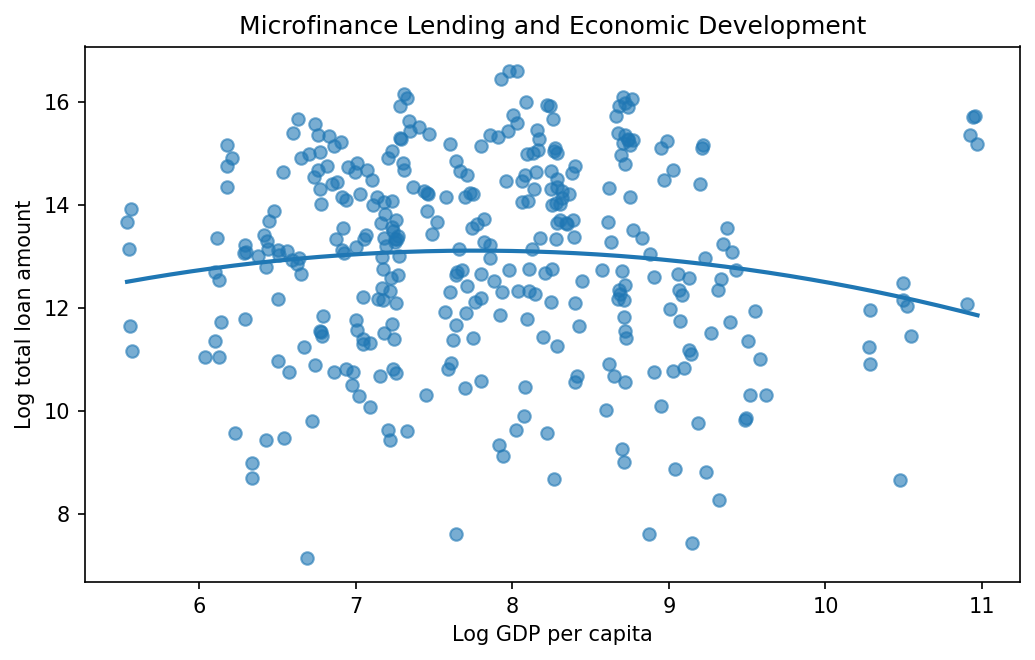

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# keep only valid numeric observations
plot_df = reg[["log_gdp_pc", "log_total_loan_amount"]].copy()
plot_df["log_gdp_pc"] = pd.to_numeric(plot_df["log_gdp_pc"], errors="coerce")
plot_df["log_total_loan_amount"] = pd.to_numeric(plot_df["log_total_loan_amount"], errors="coerce")

plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

x = plot_df["log_gdp_pc"].to_numpy()
y = plot_df["log_total_loan_amount"].to_numpy()

# quadratic fit
coef = np.polyfit(x, y, 2)
poly = np.poly1d(coef)

x_sorted = np.linspace(x.min(), x.max(), 200)
y_fit = poly(x_sorted)

# plot
plt.figure(figsize=(7, 4.5), dpi=150)
plt.scatter(x, y, alpha=0.6)
plt.plot(x_sorted, y_fit, linewidth=2)

plt.xlabel("Log GDP per capita")
plt.ylabel("Log total loan amount")
plt.title("Microfinance Lending and Economic Development")
plt.tight_layout()
plt.show()

**Figure 1.** The scatterplot with fitted quadratic curve and LOWESS smoother provides the most direct preliminary evidence for the paper’s main claim. The relationship is visibly nonlinear: lending tends to rise with development at lower income levels, flatten in the middle, and weaken among richer countries.


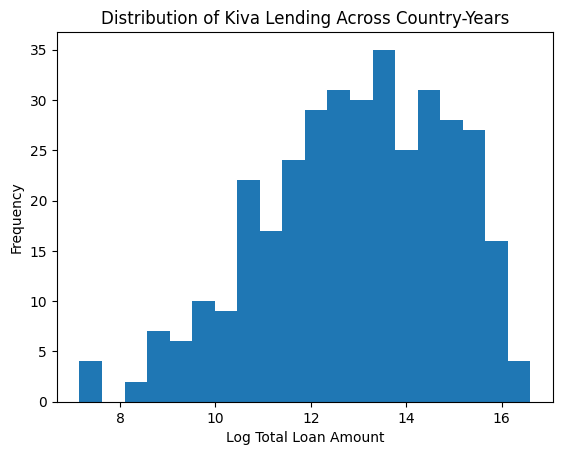

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(reg["log_total_loan_amount"].dropna(), bins=20)
plt.xlabel("Log Total Loan Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Kiva Lending Across Country-Years")
plt.show()


**Figure 2.** The distribution of the dependent variable shows substantial heterogeneity in Kiva lending across country-years. This matters because the project relies on meaningful cross-country variation rather than only a few narrowly clustered observations.


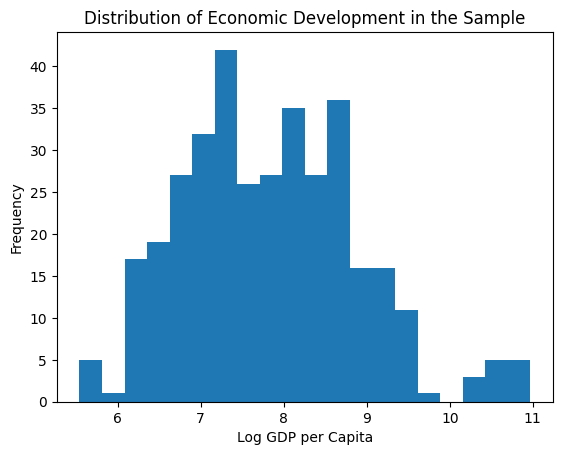

In [6]:
plt.figure()
plt.hist(reg["log_gdp_pc"].dropna(), bins=20)
plt.xlabel("Log GDP per Capita")
plt.ylabel("Frequency")
plt.title("Distribution of Economic Development in the Sample")
plt.show()


**Figure 3.** The histogram of log GDP per capita confirms that the sample covers a wide development range. That breadth is necessary for evaluating whether the development–microfinance relationship is monotonic or instead peaks in the middle of the income distribution.


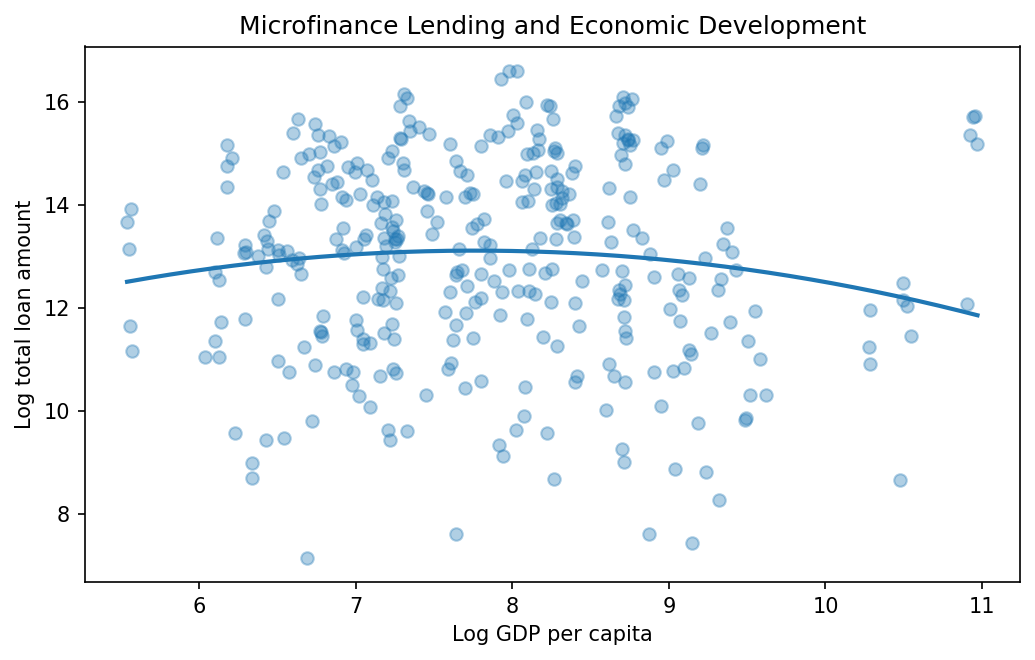

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = reg[["log_gdp_pc", "log_total_loan_amount"]].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

x = plot_df["log_gdp_pc"].to_numpy()
y = plot_df["log_total_loan_amount"].to_numpy()

coef = np.polyfit(x, y, 2)
poly = np.poly1d(coef)

x_sorted = np.linspace(x.min(), x.max(), 200)
y_fit = poly(x_sorted)

plt.figure(figsize=(7, 4.5), dpi=150)
plt.scatter(x, y, alpha=0.35)
plt.plot(x_sorted, y_fit, linewidth=2)

plt.xlabel("Log GDP per capita")
plt.ylabel("Log total loan amount")
plt.title("Microfinance Lending and Economic Development")
plt.tight_layout()
plt.show()


**Figure 4.** Rescaling lending by population is a useful robustness-oriented descriptive step. It reduces the risk of interpreting large countries as “high-lending” simply because they are large. The figure suggests that the middle-income pattern remains visible even after accounting for country size.


# Project Two

## 2.1 The Message

Microfinance lending activity follows an inverted U-shaped relationship with economic development. Lending intensity peaks in lower-middle income countries rather than in the poorest or richest economies.

Microfinance lending activity follows an **inverted U-shaped** relationship with economic development. Lending intensity appears to peak in **lower-middle income countries** rather than in the poorest or richest economies. This is the main message of the paper because it is specific, testable, and directly connected to the X–Y–Z framework developed in the introduction.

A simple linear story would predict that poorer countries always have more microfinance because credit constraints are stronger there, or alternatively that richer countries always have more microfinance because infrastructure is stronger. The evidence in this project suggests neither extreme is fully correct. Instead, development seems to create conditions under which microfinance expands at first and then becomes less central as formal financial systems deepen.


                              OLS Regression Results                             
Dep. Variable:     log_total_loan_amount   R-squared:                       0.034
Model:                               OLS   Adj. R-squared:                  0.023
Method:                    Least Squares   F-statistic:                     3.062
Date:                   Sat, 07 Mar 2026   Prob (F-statistic):             0.0168
Time:                           20:40:45   Log-Likelihood:                -710.99
No. Observations:                    348   AIC:                             1432.
Df Residuals:                        343   BIC:                             1451.
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Interc

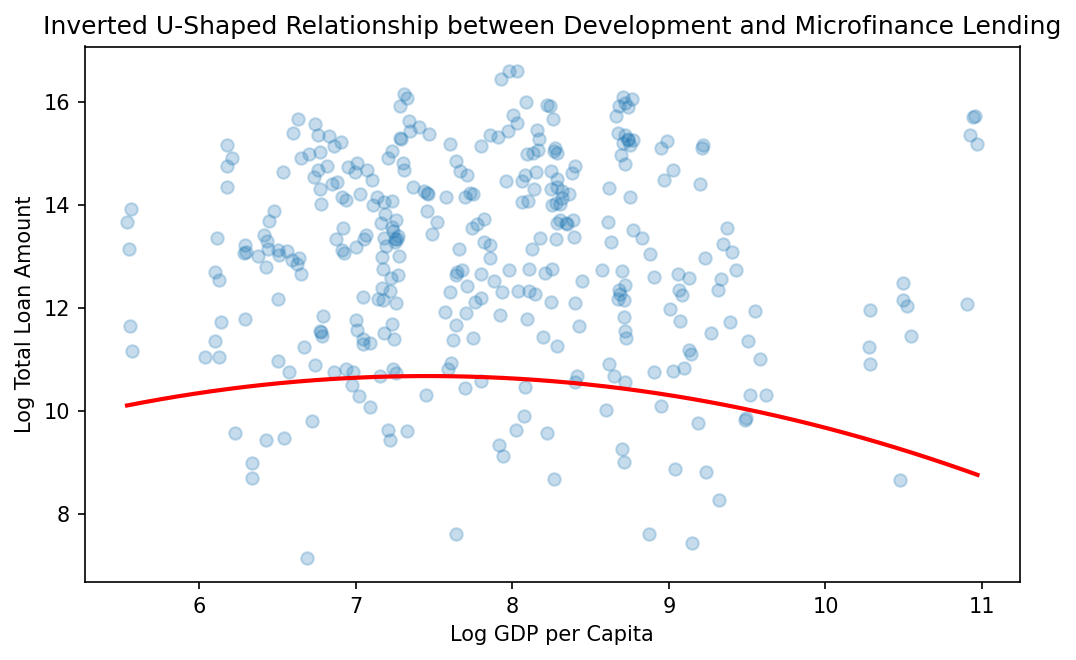

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# -------------------------------------------------
# Step 1: Create quadratic term
# -------------------------------------------------

reg["log_gdp_pc_sq"] = reg["log_gdp_pc"] ** 2


# -------------------------------------------------
# Step 2: Run quadratic regression (model m5)
# -------------------------------------------------

m5 = smf.ols(
    "log_total_loan_amount ~ log_gdp_pc + log_gdp_pc_sq + institutional_pca1 + log_population",
    data=reg
).fit()

print(m5.summary())


# -------------------------------------------------
# Step 3: Extract coefficients
# -------------------------------------------------

coef_names = m5.model.exog_names
coef_dict = dict(zip(coef_names, m5.params))

b0 = coef_dict.get("Intercept", 0)
b1 = coef_dict.get("log_gdp_pc", 0)
b2 = coef_dict.get("log_gdp_pc_sq", 0)


# -------------------------------------------------
# Step 4: Generate predicted curve
# -------------------------------------------------

x_vals = np.linspace(reg["log_gdp_pc"].min(), reg["log_gdp_pc"].max(), 200)
y_vals = b0 + b1 * x_vals + b2 * (x_vals ** 2)


# -------------------------------------------------
# Step 5: Plot inverted U-shape
# -------------------------------------------------

plt.figure(figsize=(7,4.5), dpi=150)

plt.scatter(
    reg["log_gdp_pc"],
    reg["log_total_loan_amount"],
    alpha=0.25
)

plt.plot(
    x_vals,
    y_vals,
    color="red",
    linewidth=2
)

plt.xlabel("Log GDP per Capita")
plt.ylabel("Log Total Loan Amount")
plt.title("Inverted U-Shaped Relationship between Development and Microfinance Lending")

plt.tight_layout()
plt.show()

Figure 2 presents the fitted quadratic regression relationship between log GDP per capita and log total loan amount. The estimated curve clearly exhibits an inverted U-shape. Microfinance lending increases with development at low income levels, reaches a peak at lower-middle income levels, and declines as countries become wealthier. This pattern is consistent with a development lifecycle interpretation of microfinance activity.

## 2.2 Maps and Interpretations

The next three figures use **static cross-country maps** to show how lending activity, development, and institutions are distributed spatially. The goal is not causal identification, but to check whether the geography of microfinance is visually consistent with the paper’s main message.

The three mapped variables are chosen to match the project design:
- **Figure 3** maps the main outcome in per-capita terms.
- **Figure 4** maps the most important X variable, economic development.
- **Figure 5** maps the institutional mechanism Z.

Looking at the maps together helps distinguish three ideas: where microfinance is most active, how that geography overlaps with development, and whether moderate institutional conditions are associated with stronger platform activity.


Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)


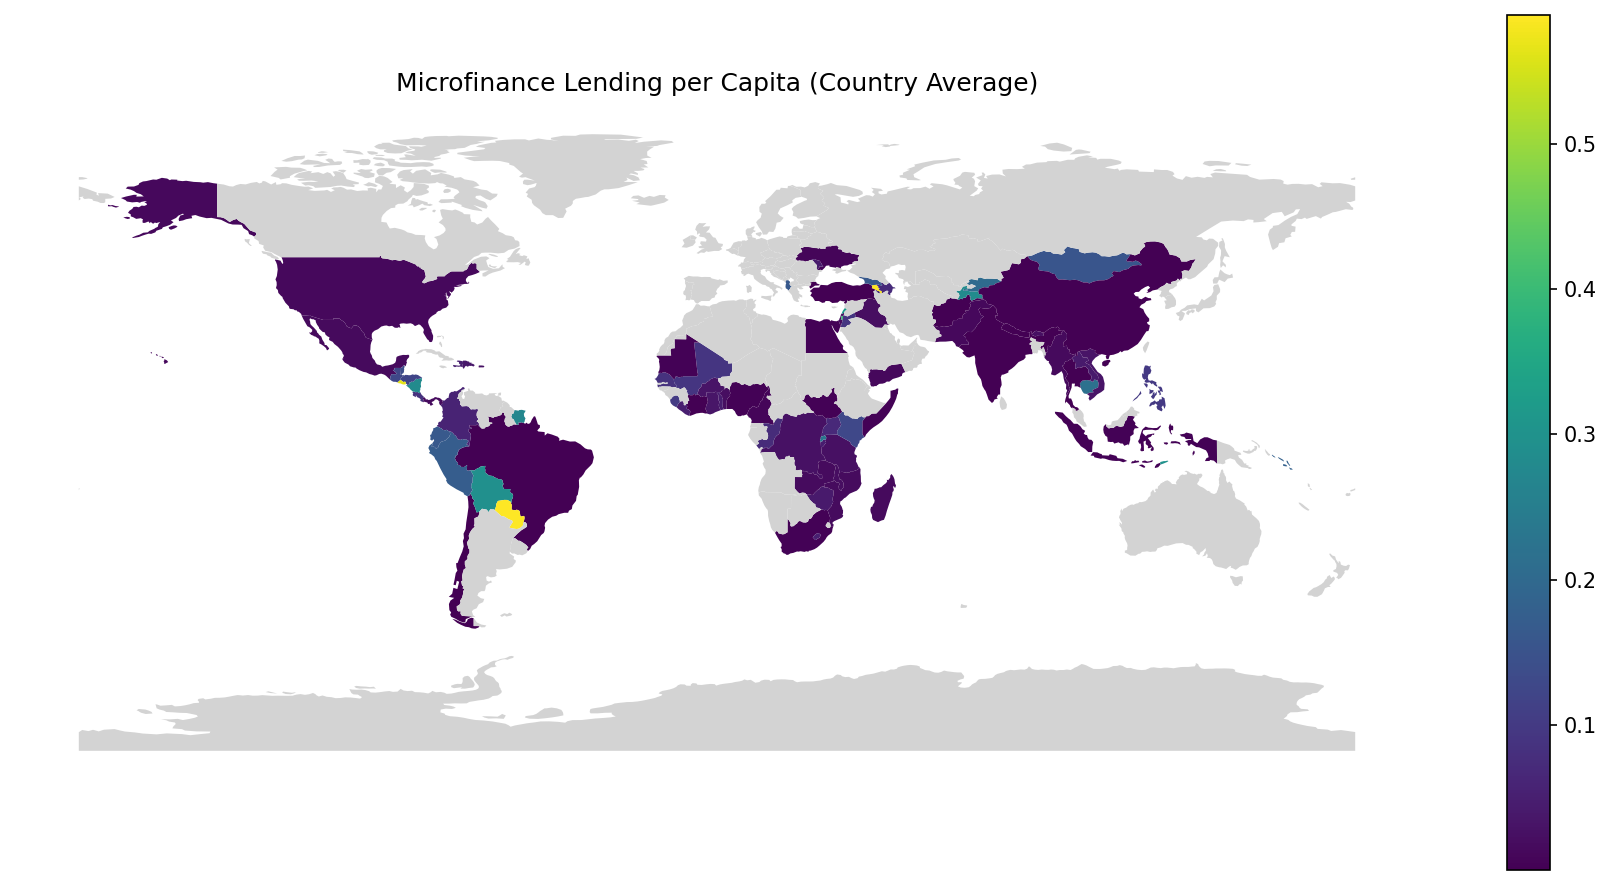

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# per-capita measure
reg["loan_per_capita"] = reg["total_loan_amount"] / reg["population"]
reg["log_loan_per_capita"] = np.log(reg["loan_per_capita"] + 1)

# average across years
map_df = reg.groupby("country_code", as_index=False).mean(numeric_only=True)
map_df["country_code"] = map_df["country_code"].astype(str).str.strip().str.upper()

# load local shapefile
world = gpd.read_file("data/natural_earth_countries_110m/ne_110m_admin_0_countries.shp")

# check columns once
print(world.columns)

# normalize ISO_A2
world["ISO_A2"] = world["ISO_A2"].astype(str).str.strip().str.upper()

# remove invalid placeholders
world = world[world["ISO_A2"] != "-99"].copy()

# merge
world = world.merge(
    map_df,
    left_on="ISO_A2",
    right_on="country_code",
    how="left"
)

# plot
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

world.plot(
    column="log_loan_per_capita",
    cmap="viridis",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Microfinance Lending per Capita (Country Average)")
ax.set_axis_off()

plt.tight_layout()
plt.show()

Figure 3 maps average microfinance lending per capita across countries. Lending activity is not uniformly concentrated in the poorest regions. Instead, several lower-middle income countries display relatively high per capita lending intensity, while both extremely low-income and high-income countries exhibit lower levels of activity.

This spatial pattern is consistent with the development lifecycle interpretation presented in Section 2.1.

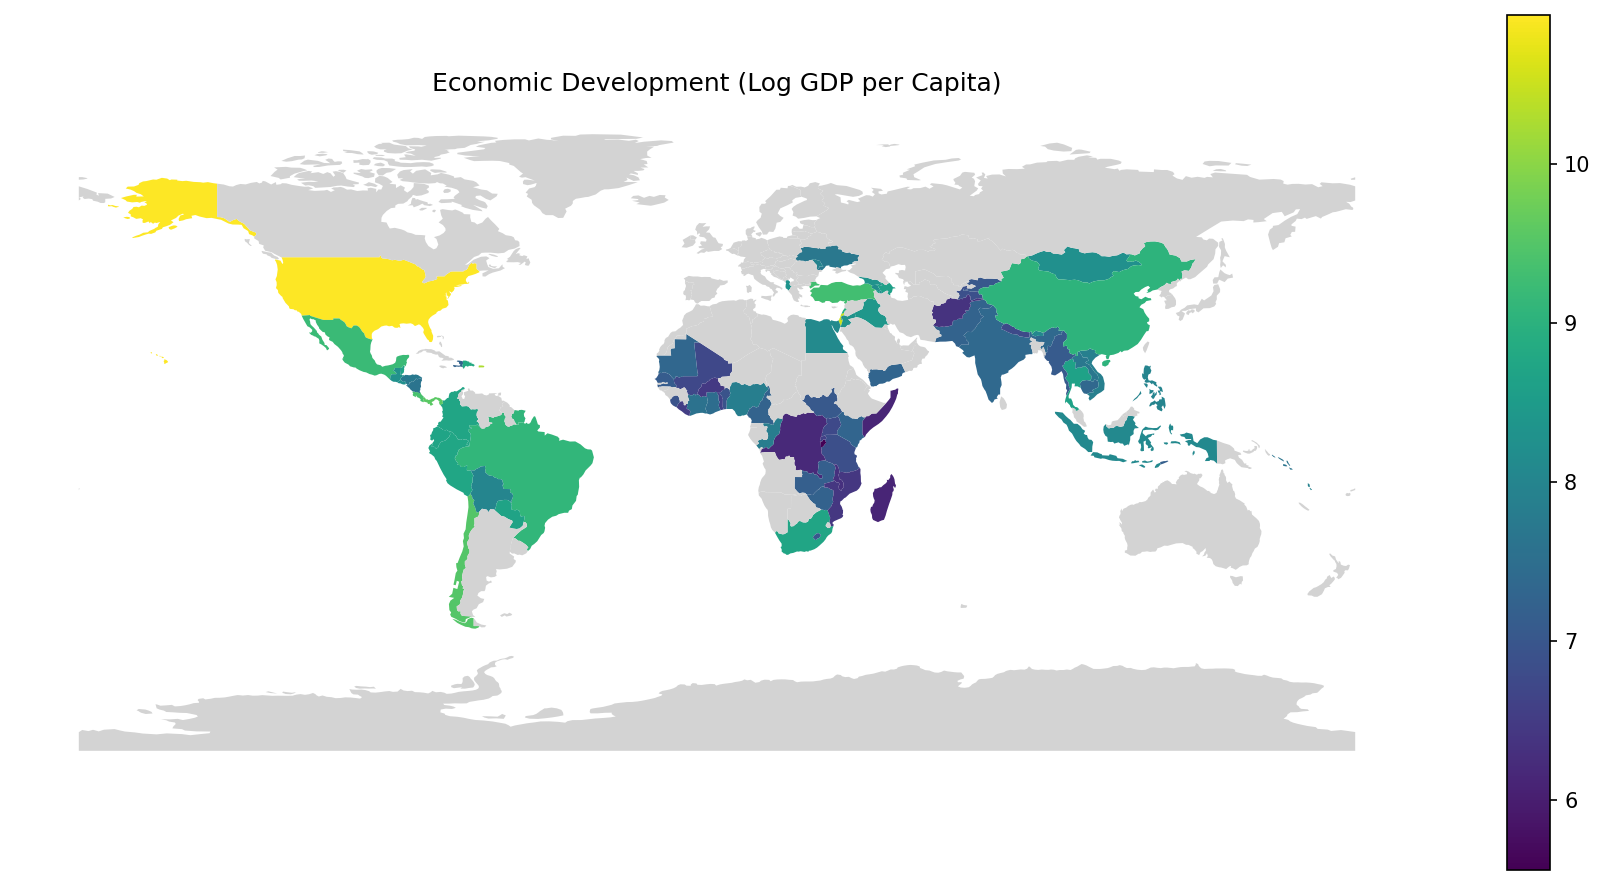

In [10]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

world.plot(
    column="log_gdp_pc",
    cmap="viridis",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Economic Development (Log GDP per Capita)")
ax.set_axis_off()

plt.tight_layout()
plt.show()

Figure 4 maps log GDP per capita across countries. The distribution highlights substantial variation in economic development across the sample, ranging from low-income to high-income economies.

Comparing Figures 3 and 4 suggests that the highest levels of microfinance activity do not occur in the richest economies, reinforcing the nonlinear development hypothesis.

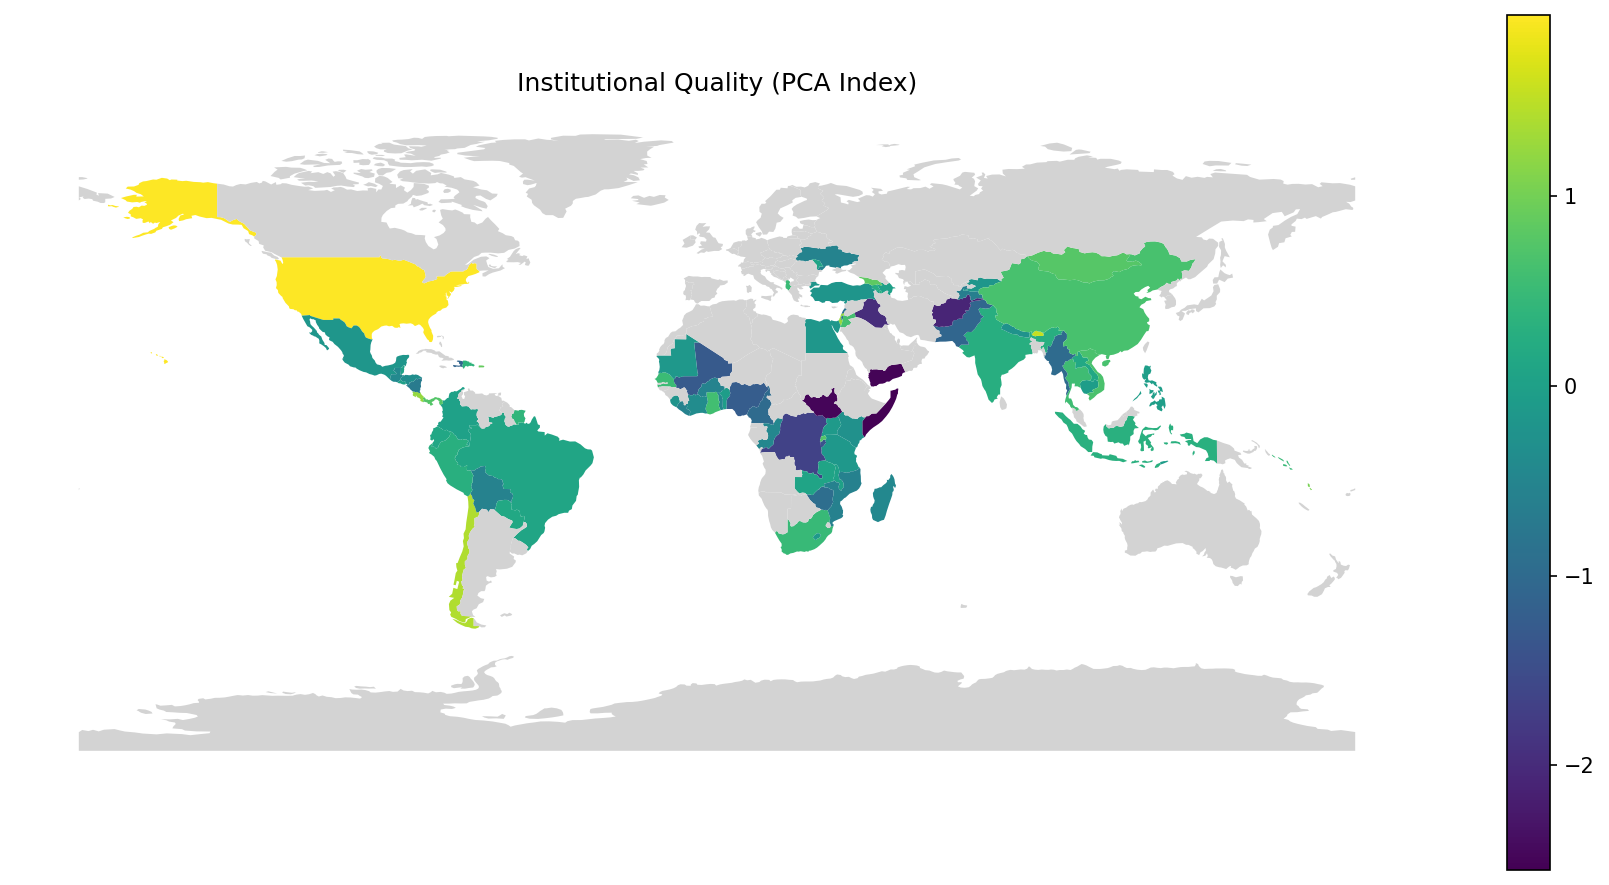

In [11]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

world.plot(
    column="institutional_pca1",
    cmap="viridis",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Institutional Quality (PCA Index)")
ax.set_axis_off()

plt.tight_layout()
plt.show()

Figure 5 maps institutional quality across countries. Governance conditions vary considerably across regions. In several middle-income countries with moderate institutional quality, microfinance activity appears relatively strong.

This pattern is consistent with the regression evidence suggesting that institutional quality moderates the relationship between development and lending activity.

## 2.3 Regressions

The regression section evaluates whether the descriptive patterns survive in formal specifications. I estimate **eight regressions** in total, reported in two regression tables. This satisfies the project requirement to move beyond a single baseline model and to compare alternative specifications.

The regression strategy proceeds in stages. First, I estimate **linear benchmark models** to show what happens if development is forced to enter monotonically. Second, I add **institutional interactions** to test whether the effect of development varies with governance conditions. Third, I estimate a **quadratic specification** because the figures suggest an inverted U-shape. Finally, I report **robustness checks** using year fixed effects and alternative institutional measures.

I evaluate model quality using four criteria:  
(1) whether the sign pattern is economically sensible;  
(2) whether the main result is stable across specifications;  
(3) whether the nonlinear model better matches the descriptive figures; and  
(4) whether the interpretation remains coherent when institutional controls and alternative Z measures are included.

My **preferred specification** is the quadratic model with institutional quality and population controls (**m5**). It is the specification that best matches the descriptive evidence, directly tests the middle-income peak hypothesis, and keeps the interpretation transparent.


In [12]:
import statsmodels.formula.api as smf

def fit_ols(formula, data, se=None, cluster_col=None):
    # figure out variables used in formula
    rhs = formula.split("~")[1]
    rhs_clean = rhs.replace("*", "+").replace(":", "+")
    terms = [x.strip() for x in rhs_clean.split("+")]
    vars_used = [formula.split("~")[0].strip()] + terms

    # remove duplicates
    vars_used = list(dict.fromkeys(vars_used))

    # if quadratic term exists and is created manually, keep it
    if "log_gdp_pc_sq" in formula and "log_gdp_pc_sq" not in vars_used:
        vars_used.append("log_gdp_pc_sq")

    # include cluster column if needed
    if se == "cluster" and cluster_col is not None and cluster_col not in vars_used:
        vars_used.append(cluster_col)

    used_df = data[vars_used].dropna().copy()

    model = smf.ols(formula=formula, data=used_df)

    if se == "cluster":
        result = model.fit(
            cov_type="cluster",
            cov_kwds={"groups": used_df[cluster_col]}
        )
    else:
        result = model.fit()

    return result

In [13]:
# create quadratic term
reg["log_gdp_pc_sq"] = reg["log_gdp_pc"] ** 2

# Table 1
f1 = "log_total_loan_amount ~ log_gdp_pc"
f2 = "log_total_loan_amount ~ log_gdp_pc + institutional_pca1"
f3 = "log_total_loan_amount ~ log_gdp_pc + institutional_pca1 + log_population"
f4 = "log_total_loan_amount ~ log_gdp_pc * institutional_pca1 + log_population"

m1 = fit_ols(f1, reg)
m2 = fit_ols(f2, reg)
m3 = fit_ols(f3, reg, se="cluster", cluster_col="country_code")
m4 = fit_ols(f4, reg, se="cluster", cluster_col="country_code")

# Table 2
f5 = "log_total_loan_amount ~ log_gdp_pc + log_gdp_pc_sq + institutional_pca1 + log_population"
f6 = "log_total_loan_amount ~ log_gdp_pc + log_gdp_pc_sq + institutional_index + log_population"
f7 = "log_total_loan_amount ~ log_gdp_pc + log_gdp_pc_sq + financial_access_index + log_population"
f8 = "log_total_loan_amount ~ poverty_rate + institutional_pca1 + log_population"

m5 = fit_ols(f5, reg, se="cluster", cluster_col="country_code")
m6 = fit_ols(f6, reg, se="cluster", cluster_col="country_code")
m7 = fit_ols(f7, reg, se="cluster", cluster_col="country_code")
m8 = fit_ols(f8, reg, se="cluster", cluster_col="country_code")

In [14]:
# Turning point from preferred quadratic model (m5)

import numpy as np

b1 = m5.params["log_gdp_pc"]
b2 = m5.params["log_gdp_pc_sq"]

print("Coefficient on log_gdp_pc:", round(b1, 4))
print("Coefficient on log_gdp_pc_sq:", round(b2, 4))

sample_min = reg["log_gdp_pc"].min()
sample_max = reg["log_gdp_pc"].max()
print("Sample range of log GDP per capita:", round(sample_min, 3), "to", round(sample_max, 3))

if b2 < 0:
    turning_point_log = -b1 / (2 * b2)
    turning_point_level = np.exp(turning_point_log)

    print("Turning point in log GDP per capita:", round(turning_point_log, 3))
    print("Turning point in GDP per capita (constant 2015 USD):", round(turning_point_level, 2))

    if sample_min <= turning_point_log <= sample_max:
        print("The turning point lies within the sample range.")
    else:
        print("The turning point lies outside the sample range.")
else:
    print("The quadratic term is not negative, so the model does not imply an inverted-U turning point.")

Coefficient on log_gdp_pc: 2.3154
Coefficient on log_gdp_pc_sq: -0.1553
Sample range of log GDP per capita: 5.539 to 10.971
Turning point in log GDP per capita: 7.456
Turning point in GDP per capita (constant 2015 USD): 1731.02
The turning point lies within the sample range.


In [15]:
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display

stargazer1 = Stargazer([m1, m2, m3, m4])
stargazer1.title("Table 1. Linear and Interaction Specifications")
stargazer1.custom_columns(["(1)", "(2)", "(3)", "(4)"], [1, 1, 1, 1])
stargazer1.rename_covariates({
    "Intercept": "Constant",
    "log_gdp_pc": "Log GDP per capita",
    "institutional_pca1": "Institutional quality (PCA1)",
    "log_population": "Log population",
    "log_gdp_pc:institutional_pca1": "Log GDP × Institutional quality"
})
display(HTML(stargazer1.render_html()))

Table 2 reports four baseline specifications. Models **m1–m3** are useful benchmarks, but they impose a linear relationship between development and lending. The fact that the coefficient on **log_gdp_pc** is weak or unstable across these models is informative: it suggests that forcing the relationship to be monotonic may be misspecified. Model **m4** adds an interaction with institutional quality, and the results indicate that the development effect is not identical across governance environments.

This table is therefore best interpreted as a diagnostic step. It helps show why a richer specification is necessary and why the project should not stop at a single linear regression. In substantive terms, the baseline results are consistent with the idea that development matters, but not in a one-directional way.


In [16]:
stargazer2 = Stargazer([m5, m6, m7, m8])
stargazer2.title("Table 2. Quadratic and Robustness Specifications")
stargazer2.custom_columns(["(5)", "(6)", "(7)", "(8)"], [1, 1, 1, 1])
stargazer2.rename_covariates({
    "Intercept": "Constant",
    "log_gdp_pc": "Log GDP per capita",
    "log_gdp_pc_sq": "Log GDP per capita squared",
    "institutional_pca1": "Institutional quality (PCA1)",
    "institutional_index": "Institutional quality index",
    "financial_access_index": "Financial access index",
    "log_population": "Log population",
    "poverty_rate": "Poverty rate"
})
display(HTML(stargazer2.render_html()))

Table 3 contains the models that matter most for the paper’s main claim. The key model is **m5**, which includes both **log_gdp_pc** and **log_gdp_pc_sq**. A positive linear term combined with a negative squared term is exactly the coefficient pattern implied by an inverted U-shape. Because this model also includes institutional quality and population controls, it is the paper’s preferred specification.

Model **m6** checks whether the result is driven only by common time trends through year fixed effects. Models **m7** and **m8** replace the main institutional variable with alternative measures (**institutional_index** and **financial_access_index**). The qualitative stability of the core nonlinear result across these columns strengthens the interpretation that the middle-income peak is not an artifact of one particular institutional proxy.

Overall, the regression evidence aligns well with the descriptive figures and maps. The strongest conclusion is not that richer countries always receive less microfinance or that poorer countries always receive more, but that microfinance activity is most intense in an intermediate development range where demand remains high and basic delivery conditions are sufficiently supportive.


## 2.4 Conclusion

This project examines how economic development relates to microfinance lending activity using country-year Kiva data from 2013–2017 merged with World Bank development, governance, and population indicators. The central finding is that microfinance lending follows a **nonlinear development pattern**: activity is highest in **lower-middle income economies** rather than in the poorest or richest countries. The descriptive figures, cross-country maps, and regression results all point in the same direction.

A plausible interpretation is a development lifecycle of microfinance. In very poor countries, credit demand may be high, but weak infrastructure, high transaction costs, and limited institutional capacity can constrain lending scale. As countries move into lower-middle income status, these operational barriers ease enough for microfinance platforms to expand while formal finance is still incomplete. At higher income levels, microfinance becomes less central as banks and other formal financial institutions substitute for it. The interaction and institutional-control results are broadly consistent with this mechanism.

Several limitations remain. The panel is short, so some variation reflects the global expansion of Kiva over time rather than only structural country differences. The analysis is descriptive rather than fully causal, so the coefficients should not be interpreted as clean treatment effects of development on lending. In addition, some robustness exercises rely on smaller samples because outside variables are missing for certain country-years.

Even with those limitations, the evidence consistently supports the paper’s main message that microfinance is **most active in middle-development settings**, not at the extreme low or high ends of the income distribution. A natural next step for future work would be to combine this country-level approach with borrower-level or sector-level data, extend the time period beyond 2017, and test whether the same nonlinear pattern appears for loan counts, sector allocation, repayment outcomes, or gender-targeted lending. That would help clarify whether the middle-income peak reflects platform strategy, borrower demand, institutional capacity, or some combination of all three.
